In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["price"].max()

13300000

In [7]:
num_col = ["bedrooms","bathrooms","stories","parking"]

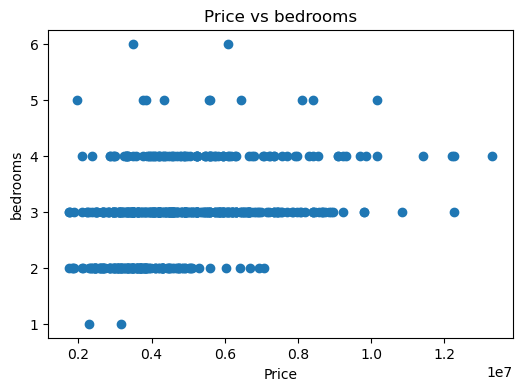

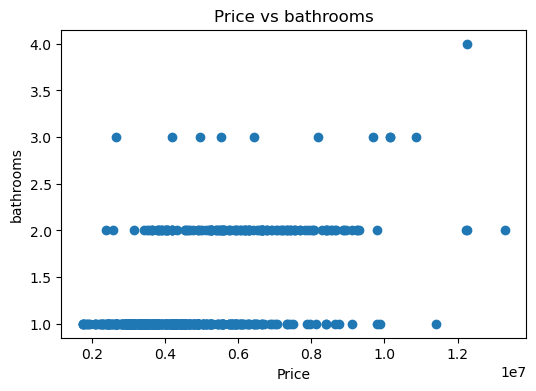

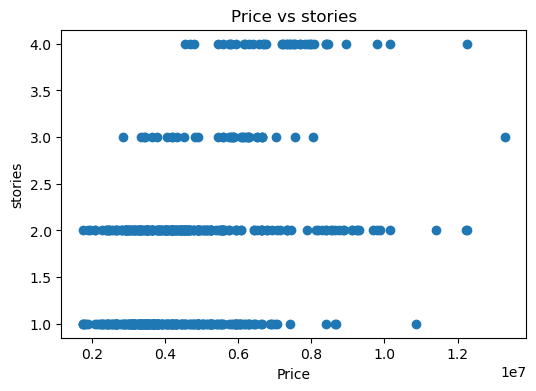

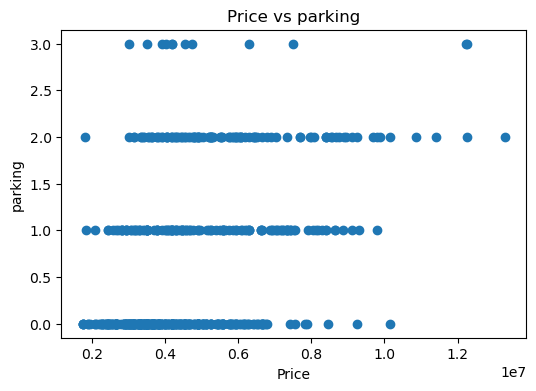

In [8]:
for col in num_col:
    plt.figure(figsize=(6, 4))  # New figure for each plot
    plt.scatter(df["price"], df[col])
    plt.xlabel("Price")
    plt.ylabel(col)
    plt.title(f"Price vs {col}")
    plt.show()
    print("\n" * 3) 
    


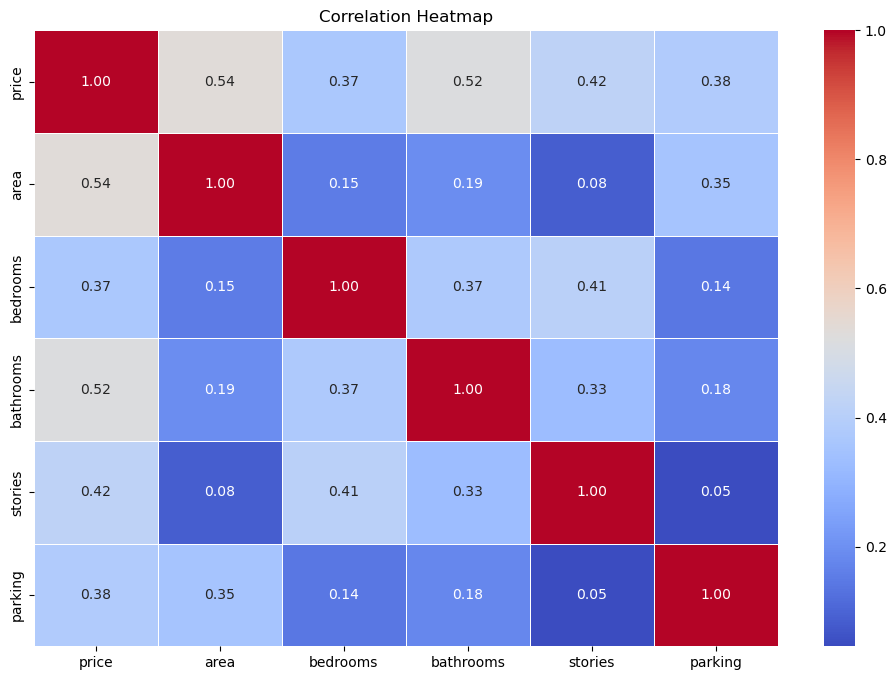

In [9]:

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),  
    annot=True,                  
    cmap="coolwarm",            
    fmt=".2f",                  
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()
# hey

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [11]:
non_numeric_cols = df.select_dtypes(exclude='number').columns.tolist()

for col in non_numeric_cols:
    df[col]=le.fit_transform(df[col])

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [13]:
X = df.drop(columns=["price"])
y = df["price"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

Linear_model = LinearRegression()

Linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = Linear_model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

r2 = r2_score(y_test, y_pred)
mean_err = mean_absolute_error(y_test, y_pred)
root_mean_squared = root_mean_squared_error(y_test, y_pred)

In [18]:
print(Linear_model.score(X_train, y_train))
print(Linear_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.68603602364727
0.6557070707485259
0.6557070707485259
906953.7908301714
1214719.0933522657


In [19]:
from sklearn.tree import DecisionTreeRegressor

In [20]:
DTR_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5)

DTR_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
y_pred_dtr = DTR_model.predict(X_test)

In [22]:
r2 = r2_score(y_test, y_pred_dtr)
mean_err = mean_absolute_error(y_test, y_pred_dtr)
root_mean_squared = root_mean_squared_error(y_test, y_pred_dtr)

In [23]:
print(DTR_model.score(X_train, y_train))
print(DTR_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.6892435720650698
0.45987709888492645
0.45987709888492645
1121256.3089919717
1521451.4621994258


In [24]:
from sklearn.linear_model import RidgeCV

alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv_model = RidgeCV(alphas=alphas_to_test, cv=10)

In [25]:
ridge_cv_model.fit(X_train,y_train)

,alphas,"[0.01, 0.1, ...]"
,fit_intercept,True
,scoring,None
,cv,10
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [26]:
y_pred_ridge = ridge_cv_model.predict(X_test)

In [27]:
r2 = r2_score(y_test, y_pred_ridge)
mean_err = mean_absolute_error(y_test, y_pred_ridge)
root_mean_squared = root_mean_squared_error(y_test, y_pred_ridge)

In [28]:
print(ridge_cv_model.score(X_train, y_train))
print(ridge_cv_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.6830994534561357
0.650650493793114
0.650650493793114
909934.1103142081
1223606.7749412623


In [29]:
from sklearn.linear_model import LassoCV

alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
lasso_cv_model = LassoCV(alphas=alphas_to_test, cv=10, random_state=42)

In [30]:
lasso_cv_model.fit(X_train,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,"[0.01, 0.1, ...]"
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,10
,verbose,False
,n_jobs,None


In [31]:
y_pred_lasso = lasso_cv_model.predict(X_test)

In [32]:
r2 = r2_score(y_test, y_pred_lasso)
mean_err = mean_absolute_error(y_test, y_pred_lasso)
root_mean_squared = root_mean_squared_error(y_test, y_pred_lasso)

In [33]:
print(lasso_cv_model.score(X_train, y_train))
print(lasso_cv_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.6860360236472685
0.6557070664961263
0.6557070664961263
906953.7942923127
1214719.1008538296


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor_model = RandomForestRegressor(
    max_depth=10, 
    random_state=42, 
    min_samples_split=10, 
    min_samples_leaf=5
)

rf_regressor_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_rf_pred = rf_regressor_model.predict(X_test)

In [36]:
r2 = r2_score(y_test, y_rf_pred)
mean_err = mean_absolute_error(y_test, y_rf_pred)
root_mean_squared = root_mean_squared_error(y_test, y_rf_pred)

In [37]:
print(rf_regressor_model.score(X_train, y_train))
print(rf_regressor_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.7556253524594692
0.6169880090706055
0.6169880090706055
960208.5413860149
1281203.1311941026


In [42]:
from sklearn.ensemble import AdaBoostRegressor

In [54]:
ADA_model = AdaBoostRegressor(n_estimators=100, random_state=42)

ADA_model.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,loss,'linear'
,random_state,42


In [55]:
y_pred_ADA = ADA_model.predict(X_test)

In [56]:
r2 = r2_score(y_test, y_pred_ADA)
mean_err = mean_absolute_error(y_test, y_pred_ADA)
root_mean_squared = root_mean_squared_error(y_test, y_pred_ADA)

In [53]:
print(ADA_model.score(X_train, y_train))
print(ADA_model.score(X_test, y_test))
print(r2)
print(mean_err)
print(root_mean_squared)

0.6836334385960032
0.5233087384287188
0.5233087384287188
1091912.3230175728
1429323.0632985309
